# ERlytics: Forecasting Influenza-Related Emergency Department Visits in Pennsylvania

**Project Objective**
Use weekly CDC NSSP emergency department data to identify seasonal patterns in influenza-related visits
and compare several forecasting methods for short-term planning.

**Forecast Target**
Weekly percentage of emergency department visits associated with influenza in Pennsylvania.

**Models Compared**
1. Seasonal Naive
2. SARIMA
3. ETS / Holt-Winters

**Evaluation Strategy**
- Training period: used to estimate model parameters
- Validation period: used to compare forecasting methods
- Final test period: used for final out-of-sample evaluation

This structure keeps model comparison separate from the final test period.

In [2]:
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Load the CDC NSSP Dataset

The script first searches for a CSV file beginning with `NSSP`.
If the file is not found automatically, replace `CSV_PATH` with the correct local path.

In [3]:
csv_files = glob.glob("NSSP*.csv")

if len(csv_files) > 0:
    CSV_PATH = csv_files[0]
else:
    CSV_PATH = "NSSP_Emergency_Department_Visit_Trajectories.csv"

print("Using file:", CSV_PATH)

df = pd.read_csv(CSV_PATH)

print("\nDataset shape:")
print(df.shape)

print("\nFirst five rows:")
print(df.head())

print("\nAvailable columns:")
print(df.columns.tolist())

Using file: NSSP_Emergency_Department_Visit.csv

Dataset shape:
(664144, 20)

First five rows:
     week_end geography    county  percent_visits_combined  \
0  2022-10-01   Alabama      Bibb                      NaN   
1  2022-10-01   Alabama   Calhoun                      NaN   
2  2022-10-01   Alabama   Chilton                      NaN   
3  2022-10-01   Alabama  Cleburne                      NaN   
4  2022-10-01   Alabama     Coosa                      NaN   

   percent_visits_covid  percent_visits_influenza  percent_visits_rsv  \
0                   NaN                       NaN                 NaN   
1                   NaN                       NaN                 NaN   
2                   NaN                       NaN                 NaN   
3                   NaN                       NaN                 NaN   
4                   NaN                       NaN                 NaN   

   percent_visits_smoothed_combined  percent_visits_smoothed_covid  \
0                      

## 2. Filter Pennsylvania Statewide Influenza Data

The statewide Pennsylvania series is used because the disease-specific data is more complete
than the county-level series.

The variable of interest is `percent_visits_influenza`.

In [4]:
pa = df[
    (df["geography"] == "Pennsylvania") &
    (df["county"] == "All")
].copy()

pa["week_end"] = pd.to_datetime(pa["week_end"])
pa = pa.sort_values("week_end")

flu = pa[
    ["week_end", "percent_visits_influenza"]
].dropna().copy()

flu = flu.set_index("week_end").sort_index()

print("\nNumber of influenza observations:", len(flu))
print("Date range:", flu.index.min(), "to", flu.index.max())
print("Missing values:", flu["percent_visits_influenza"].isna().sum())


Number of influenza observations: 208
Date range: 2022-10-01 00:00:00 to 2026-09-19 00:00:00
Missing values: 0


## 3. Exploratory Time-Series Plot

The original series is plotted to evaluate:
- long-term trend
- seasonal behavior
- peak timing
- changes in peak magnitude

Influenza-related ED visits are expected to increase during winter months and decline during summer.

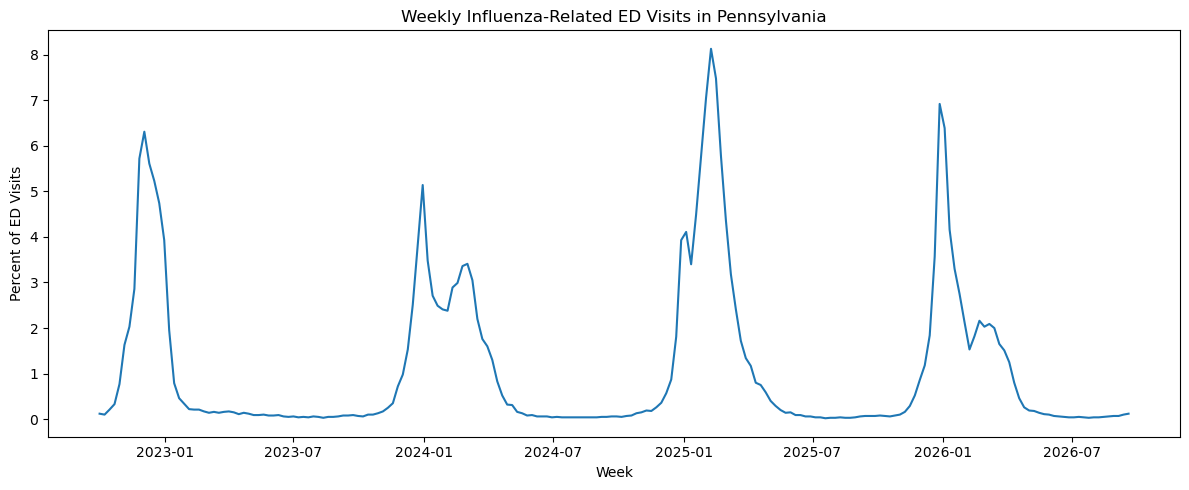

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(
    flu.index,
    flu["percent_visits_influenza"]
)

plt.xlabel("Week")
plt.ylabel("Percent of ED Visits")
plt.title("Weekly Influenza-Related ED Visits in Pennsylvania")
plt.tight_layout()
plt.show()

## 4. Autocorrelation of the Original Series

The ACF measures correlation between the current observation and its previous values.

For weekly data:
- short lags show short-term persistence
- lag 52 represents approximately one year

A rise in autocorrelation near lag 52 is consistent with annual influenza seasonality.

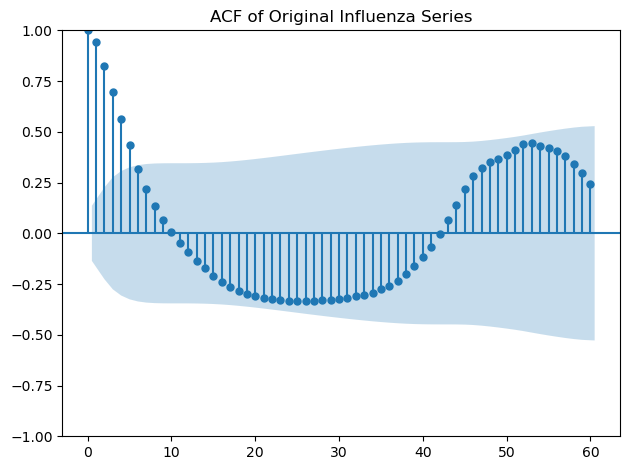

In [6]:
plot_acf(
    flu["percent_visits_influenza"],
    lags=60
)

plt.title("ACF of Original Influenza Series")
plt.tight_layout()
plt.show()

## 5. Seasonal Differencing

A 52-week seasonal difference is applied:

y(t) - y(t-52)

This compares each week with the same week one year earlier and helps remove recurring annual seasonality.

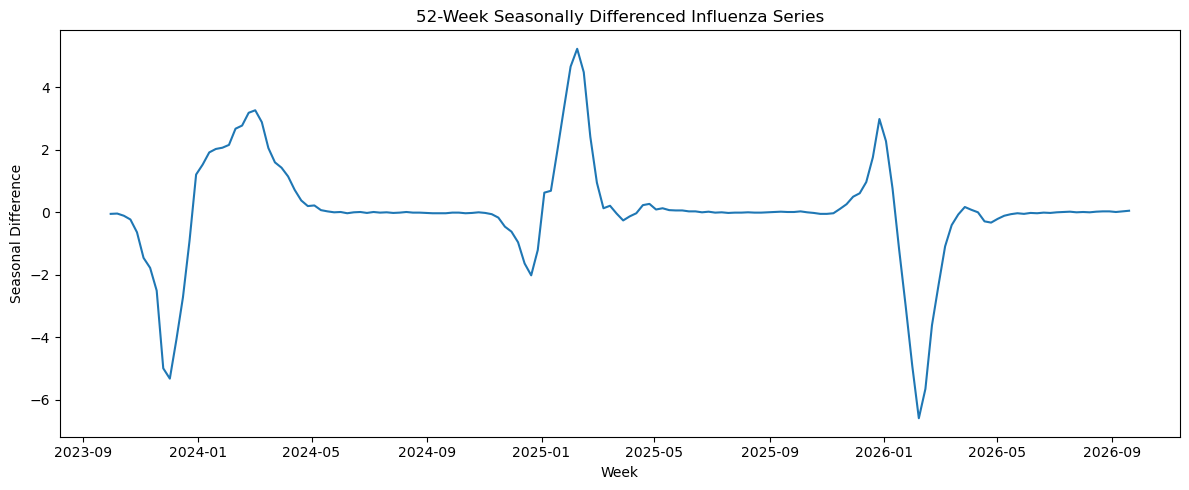

In [7]:
flu["seasonal_diff"] = (
    flu["percent_visits_influenza"]
    - flu["percent_visits_influenza"].shift(52)
)

plt.figure(figsize=(12, 5))
plt.plot(flu.index, flu["seasonal_diff"])

plt.xlabel("Week")
plt.ylabel("Seasonal Difference")
plt.title("52-Week Seasonally Differenced Influenza Series")
plt.tight_layout()
plt.show()

## 6. ACF and PACF After Seasonal Differencing

The ACF is checked again to determine whether the annual pattern has been reduced.

The PACF is used to examine short-term autoregressive structure after seasonal effects are removed.

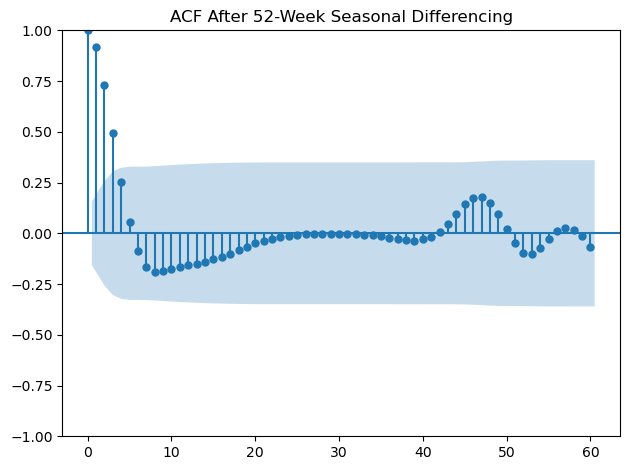

In [8]:
plot_acf(
    flu["seasonal_diff"].dropna(),
    lags=60
)

plt.title("ACF After 52-Week Seasonal Differencing")
plt.tight_layout()
plt.show()

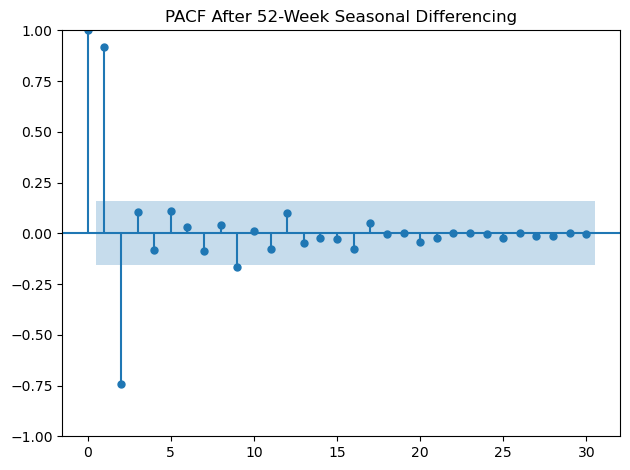

In [9]:
plot_pacf(
    flu["seasonal_diff"].dropna(),
    lags=30,
    method="ywm"
)

plt.title("PACF After 52-Week Seasonal Differencing")
plt.tight_layout()
plt.show()

## 7. Direct Lag-Correlation Analysis

Two relationships are especially useful:

- **Lag 1:** relationship between this week and the previous week
- **Lag 52:** relationship between this week and the same week one year earlier

These correlations provide an intuitive interpretation of short-term persistence and annual seasonality.

In [10]:
target = flu["percent_visits_influenza"]

lag_1_corr = target.corr(target.shift(1))
lag_52_corr = target.corr(target.shift(52))

print("\nLag correlations:")
print("Lag 1 correlation:", round(lag_1_corr, 4))
print("Lag 52 correlation:", round(lag_52_corr, 4))


Lag correlations:
Lag 1 correlation: 0.9431
Lag 52 correlation: 0.5661


### Lag 1 Scatter Plot
A strong linear relationship suggests that influenza ED activity changes gradually from week to week.

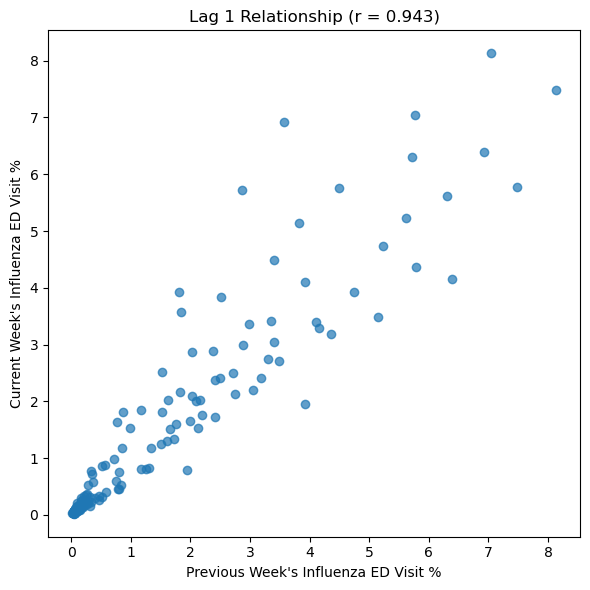

In [11]:
lag1_df = pd.DataFrame({
    "Current Week": target,
    "Previous Week": target.shift(1)
}).dropna()

plt.figure(figsize=(6, 6))
plt.scatter(
    lag1_df["Previous Week"],
    lag1_df["Current Week"],
    alpha=0.7
)

plt.xlabel("Previous Week's Influenza ED Visit %")
plt.ylabel("Current Week's Influenza ED Visit %")
plt.title(f"Lag 1 Relationship (r = {lag_1_corr:.3f})")
plt.tight_layout()
plt.show()

### Lag 52 Scatter Plot
This plot compares each observation with the same week one year earlier.
A positive relationship supports recurring annual seasonality.

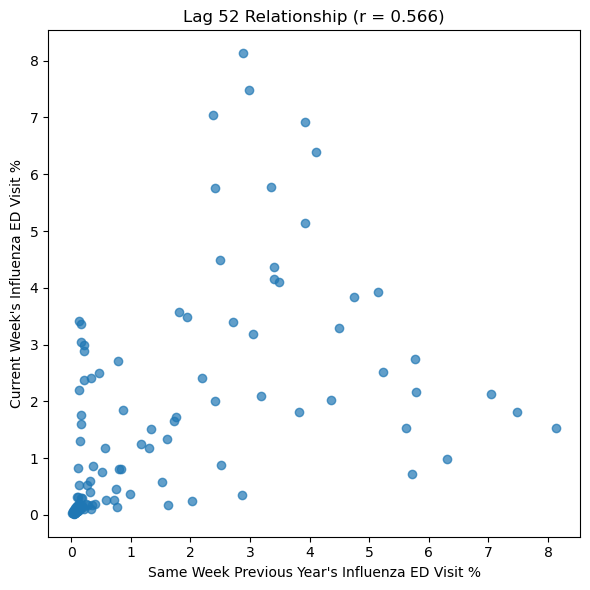

In [12]:
lag52_df = pd.DataFrame({
    "Current Week": target,
    "Same Week Last Year": target.shift(52)
}).dropna()

plt.figure(figsize=(6, 6))
plt.scatter(
    lag52_df["Same Week Last Year"],
    lag52_df["Current Week"],
    alpha=0.7
)

plt.xlabel("Same Week Previous Year's Influenza ED Visit %")
plt.ylabel("Current Week's Influenza ED Visit %")
plt.title(f"Lag 52 Relationship (r = {lag_52_corr:.3f})")
plt.tight_layout()
plt.show()

### Correlation Across Multiple Lags
This plot summarizes the correlation pattern from lag 1 through lag 60.
The vertical reference line marks lag 52.

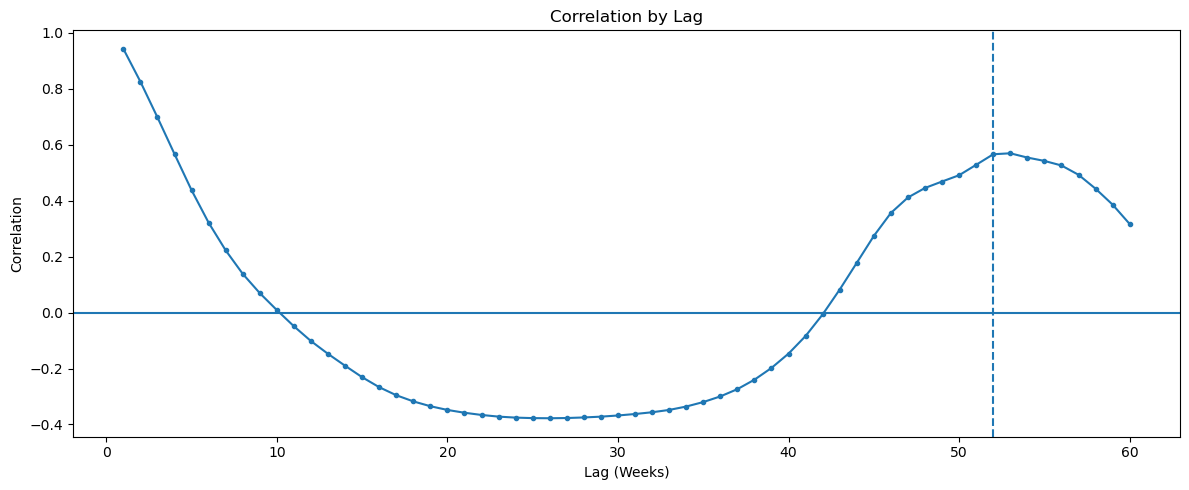

In [13]:
lag_corr = []

for lag in range(1, 61):
    corr = target.corr(target.shift(lag))
    lag_corr.append(corr)

plt.figure(figsize=(12, 5))
plt.plot(
    range(1, 61),
    lag_corr,
    marker="o",
    markersize=3
)

plt.axhline(0)
plt.axvline(52, linestyle="--")

plt.xlabel("Lag (Weeks)")
plt.ylabel("Correlation")
plt.title("Correlation by Lag")
plt.tight_layout()
plt.show()

## 8. Stationarity Test

The Augmented Dickey-Fuller test is applied to the seasonally differenced series.

**Null hypothesis:** the series contains a unit root and is non-stationary.

If the p-value is below 0.05, the null hypothesis is rejected.

In [14]:
adf_result = adfuller(
    flu["seasonal_diff"].dropna()
)

print("\nADF Test Results")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: reject the unit-root null hypothesis.")
    print("The seasonally differenced series appears stationary.")
else:
    print("Conclusion: fail to reject the unit-root null hypothesis.")
    print("Additional differencing may be required.")


ADF Test Results
ADF Statistic: -6.443488921246328
p-value: 1.5867694019120795e-08
Conclusion: reject the unit-root null hypothesis.
The seasonally differenced series appears stationary.


/var/folders/gg/jrs0677j3dg1292v5xmr5fm80000gn/T/ipykernel_49036/1639078302.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(


## 9. Training, Validation, and Final Test Split

The series is split chronologically:

- **Training:** through September 21, 2024
- **Validation:** September 28, 2024 through September 20, 2025
- **Final Test:** September 27, 2025 onward

The validation period is used for model selection.
The final test period is reserved for the final evaluation.

In [15]:
train_model = target.loc[:"2024-09-21"]

validation = target.loc[
    "2024-09-28":"2025-09-20"
]

test = target.loc["2025-09-27":]

print("\nSplit sizes:")
print("Training:", len(train_model))
print("Validation:", len(validation))
print("Final Test:", len(test))


Split sizes:
Training: 104
Validation: 52
Final Test: 52


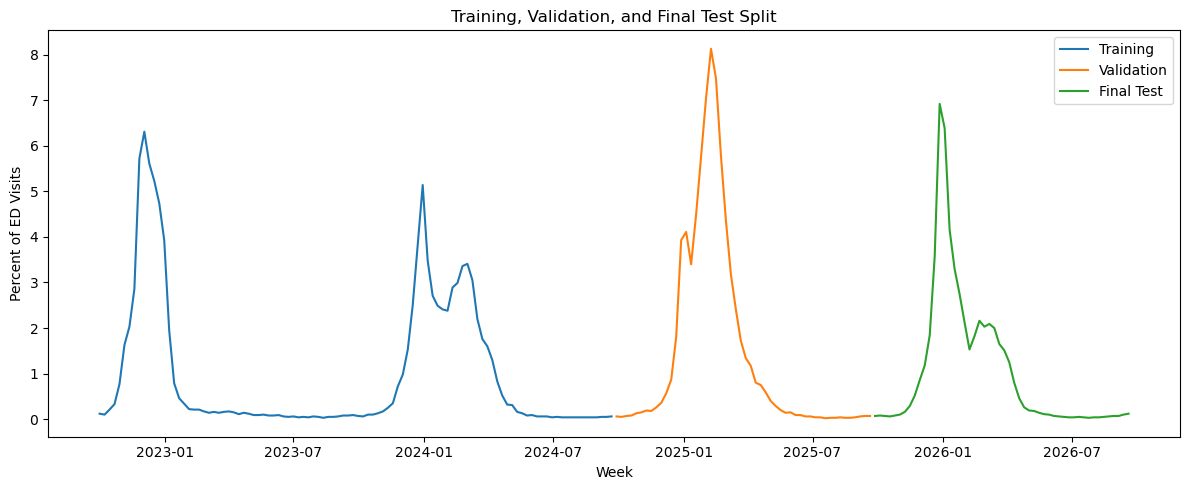

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(train_model, label="Training")
plt.plot(validation, label="Validation")
plt.plot(test, label="Final Test")

plt.xlabel("Week")
plt.ylabel("Percent of ED Visits")
plt.title("Training, Validation, and Final Test Split")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Model 1: Seasonal Naive

The Seasonal Naive model predicts each week using the value from the same week one year earlier:

y_hat(t) = y(t-52)

This is an important benchmark because influenza has strong annual seasonality.

In [17]:
seasonal_naive_val = (
    target.shift(52)
    .loc[validation.index]
)

mae_naive_val = mean_absolute_error(
    validation,
    seasonal_naive_val
)

rmse_naive_val = np.sqrt(
    mean_squared_error(
        validation,
        seasonal_naive_val
    )
)

## 11. Model 2: SARIMA

The ACF/PACF diagnostics suggest short-term autoregressive behavior after seasonal differencing.

Candidate model:

SARIMA(2,0,0)(0,1,0)[52]

The seasonal period is 52 weeks.

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    sarima_model = SARIMAX(
        train_model,
        order=(2, 0, 0),
        seasonal_order=(0, 1, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima_model.fit(disp=False)

sarima_val = sarima_fit.forecast(
    steps=len(validation)
)

sarima_val.index = validation.index

mae_sarima_val = mean_absolute_error(
    validation,
    sarima_val
)

rmse_sarima_val = np.sqrt(
    mean_squared_error(
        validation,
        sarima_val
    )
)

## 12. Model 3: ETS / Holt-Winters

ETS is used as a second seasonal forecasting approach.

The model uses:
- no explicit trend
- additive seasonality
- 52-week seasonal period

In [19]:
ets_model = ExponentialSmoothing(
    train_model,
    trend=None,
    seasonal="add",
    seasonal_periods=52
)

ets_fit = ets_model.fit()

ets_val = ets_fit.forecast(
    len(validation)
)

ets_val.index = validation.index

mae_ets_val = mean_absolute_error(
    validation,
    ets_val
)

rmse_ets_val = np.sqrt(
    mean_squared_error(
        validation,
        ets_val
    )
)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


## 13. Validation Performance Comparison

Two error metrics are used:

- **MAE:** average absolute forecast error
- **RMSE:** penalizes large forecasting errors more strongly

Lower values indicate better forecasting performance.

In [20]:
results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA(2,0,0)(0,1,0,52)",
        "ETS"
    ],
    "MAE": [
        mae_naive_val,
        mae_sarima_val,
        mae_ets_val
    ],
    "RMSE": [
        rmse_naive_val,
        rmse_sarima_val,
        rmse_ets_val
    ]
})

print("\nValidation Results:")
print(results.to_string(index=False))


Validation Results:
                  Model      MAE     RMSE
         Seasonal Naive 0.645577 1.403167
SARIMA(2,0,0)(0,1,0,52) 0.645793 1.403577
                    ETS 1.171891 2.063459


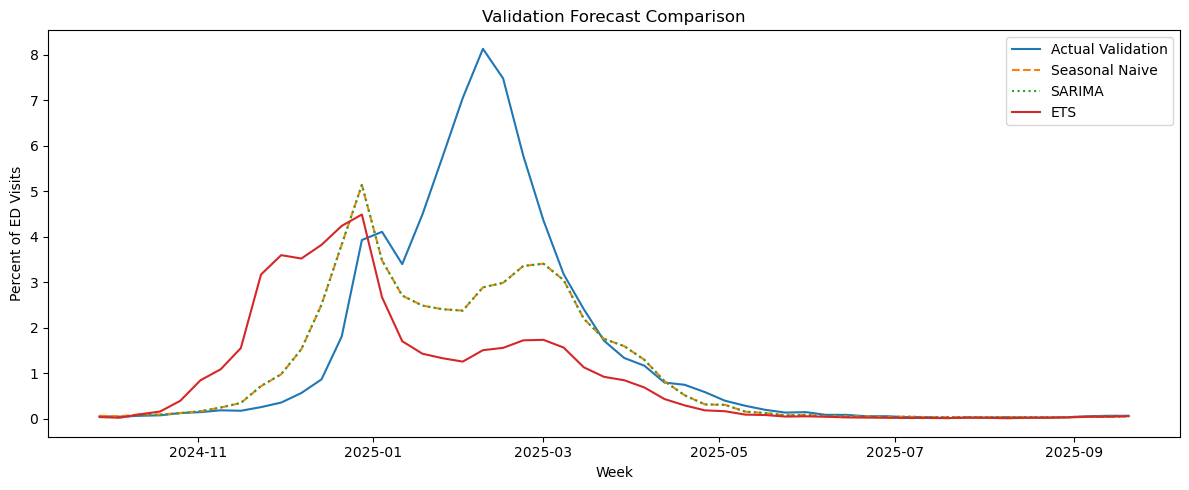

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation,
    label="Actual Validation"
)

plt.plot(
    seasonal_naive_val,
    label="Seasonal Naive",
    linestyle="--"
)

plt.plot(
    sarima_val,
    label="SARIMA",
    linestyle=":"
)

plt.plot(
    ets_val,
    label="ETS"
)

plt.xlabel("Week")
plt.ylabel("Percent of ED Visits")
plt.title("Validation Forecast Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Compare Validation Errors Visually

These charts make it easier to compare MAE and RMSE across the three candidate models.

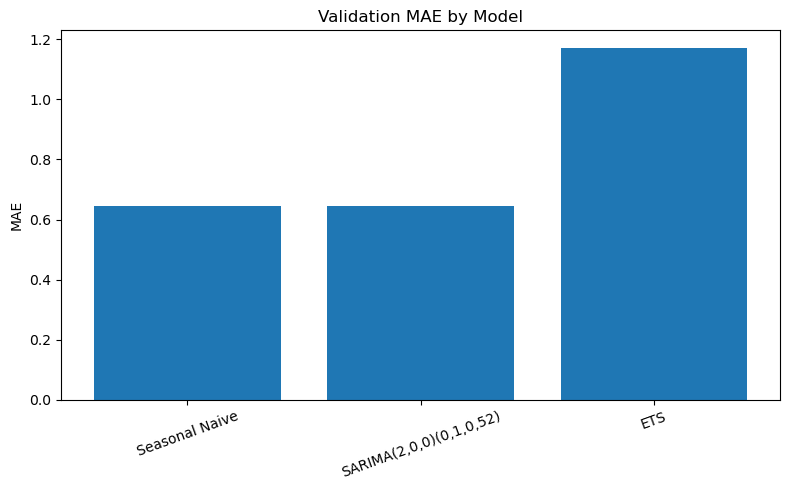

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    results["Model"],
    results["MAE"]
)

plt.ylabel("MAE")
plt.title("Validation MAE by Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

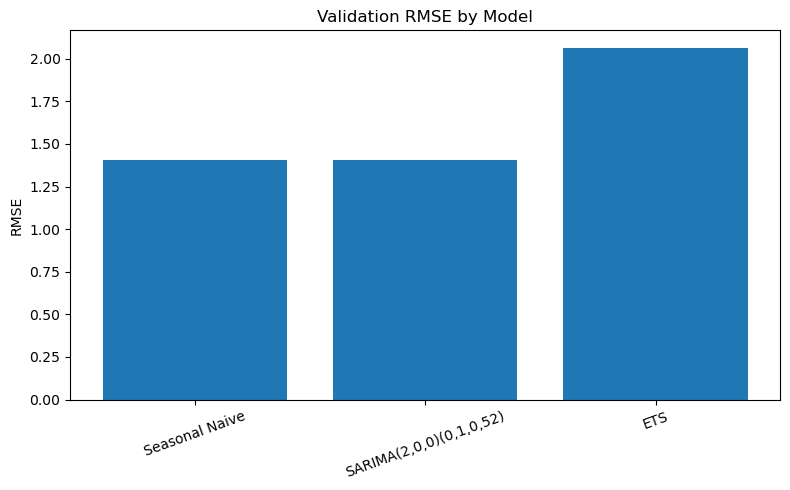

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Validation RMSE by Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 15. Final Model Selection

The model with the lowest validation error is selected for final evaluation.

In the current analysis, the Seasonal Naive model performs as well as or slightly better than the
more complex alternatives.

This suggests that the strong annual influenza pattern provides substantial predictive value,
while the more complex models do not add enough improvement during the validation period.

In [24]:
best_model = results.sort_values(
    by=["MAE", "RMSE"]
).iloc[0]

print("\nBest validation model:")
print(best_model)


Best validation model:
Model    Seasonal Naive
MAE            0.645577
RMSE           1.403167
Name: 0, dtype: object


## 16. Final Test Evaluation

The selected Seasonal Naive model is evaluated on the final 2025-26 test season.

This provides an out-of-sample measure of forecasting performance after model selection.

In [25]:
seasonal_naive_test = (
    target.shift(52)
    .loc[test.index]
)

mae_test = mean_absolute_error(
    test,
    seasonal_naive_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        test,
        seasonal_naive_test
    )
)

print("\nFinal Test Results")
print("MAE:", mae_test)
print("RMSE:", rmse_test)


Final Test Results
MAE: 0.7874999999999999
RMSE: 1.6980526176499042


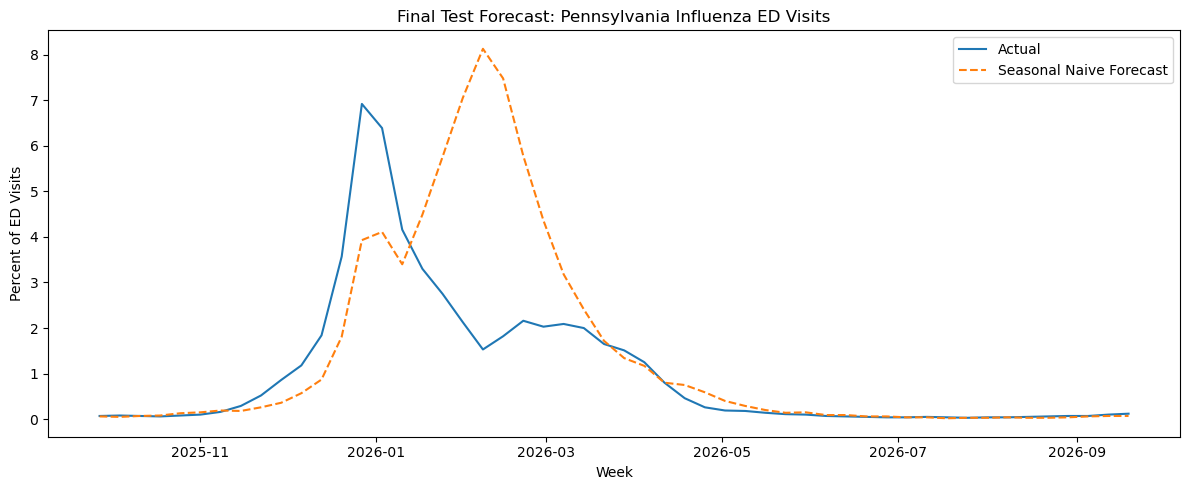

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    seasonal_naive_test,
    label="Seasonal Naive Forecast",
    linestyle="--"
)

plt.xlabel("Week")
plt.ylabel("Percent of ED Visits")
plt.title("Final Test Forecast: Pennsylvania Influenza ED Visits")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Interpretation

Main findings:

- Pennsylvania influenza-related ED visits show strong annual seasonality.
- Nearby weeks are highly correlated.
- The annual seasonal pattern is visible around lag 52.
- Seasonal differencing removes much of the recurring yearly structure.
- Seasonal Naive and SARIMA perform similarly on the validation period.
- ETS performs worse in this comparison.
- Predicting the exact timing and magnitude of winter influenza peaks remains difficult.

Practical implication:

ERlytics can provide a simple early-warning benchmark for expected seasonal influenza demand,
but historical seasonality alone may not fully explain large year-to-year changes.